# Random Forest Crime Prediction Assignment
Haley Benge <br>
 March 25th, 2026 <br>
 CIS 3902 <br>

## Overview
In this assignment, you will use a **recent real-world crime dataset** to build a **Random Forest classification model**. You will explore the data, prepare it for modeling, train a classifier, evaluate the results, and interpret feature importance.

## Learning Goals
By the end of this assignment, you should be able to:

- explain the difference between **features** and a **target variable**
- prepare data for machine learning
- build a **Random Forest** classifier in Python
- evaluate a classification model using accuracy, a confusion matrix, and a classification report
- interpret **feature importance**
- connect model results to real-world patterns and possible limitations

## Important Note
In this notebook, you are **not predicting whether a crime will happen**.  
You are predicting:

> **Was an arrest made?** (`True` or `False`)

That means your model is learning patterns related to **arrest outcomes**, not crime occurrence itself.


## Step 1: Load the Data

We will use a recent subset of the Chicago crime dataset. The dataset is large, so we will pull a manageable sample for class use.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$limit=50000"
df = pd.read_csv(url)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14140439,JK185833,2026-03-17T00:00:00.000,067XX S KENNETH AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,VEHICLE NON-COMMERCIAL,False,False,...,23,65.0,14,1147870.0,1859576.0,2026,2026-03-24T15:42:06.000,41.770622,-87.733525,"\n, \n(41.770622109, -87.733525323)"
1,14139277,JK184295,2026-03-17T00:00:00.000,036XX S WABASH AVE,0460,BATTERY,SIMPLE,SCHOOL - PUBLIC GROUNDS,False,False,...,3,35.0,08B,1177328.0,1880737.0,2026,2026-03-24T15:42:06.000,41.828075,-87.624904,"\n, \n(41.8280754, -87.624904486)"
2,14140801,JK185941,2026-03-17T00:00:00.000,027XX W FOSTER AVE,0281,CRIMINAL SEXUAL ASSAULT,NON-AGGRAVATED,HOSPITAL BUILDING / GROUNDS,False,False,...,40,4.0,02,1157125.0,1934423.0,2026,2026-03-24T15:42:06.000,41.975828,-87.697568,"\n, \n(41.975827666, -87.697567585)"
3,14140013,JK185242,2026-03-17T00:00:00.000,071XX W NORTH AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,False,False,...,29,25.0,26,1128690.0,1909850.0,2026,2026-03-24T15:42:06.000,41.908928,-87.802695,"\n, \n(41.90892793, -87.802694881)"
4,14139113,JK184012,2026-03-17T00:00:00.000,075XX S STONY ISLAND AVE,1320,CRIMINAL DAMAGE,TO VEHICLE,HOSPITAL BUILDING / GROUNDS,False,False,...,8,43.0,14,1188234.0,1855158.0,2026,2026-03-24T15:42:06.000,41.757631,-87.585708,"\n, \n(41.757630995, -87.585708249)"


## Step 2: Explore the Data

Look at the structure of the dataset.

### Questions
1. What does each row represent? <br>
Each row represents a case or crime that was committed.
2. Which variables look potentially useful for prediction? <br>
Primary_type, description and arrest look useful for prediction.
3. Which variable appears to be the target for this assignment? <br>
Arrest is the target variable for this assignent.


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    50000 non-null  int64  
 1   case_number           50000 non-null  object 
 2   date                  50000 non-null  object 
 3   block                 50000 non-null  object 
 4   iucr                  50000 non-null  object 
 5   primary_type          50000 non-null  object 
 6   description           50000 non-null  object 
 7   location_description  49753 non-null  object 
 8   arrest                50000 non-null  bool   
 9   domestic              50000 non-null  bool   
 10  beat                  50000 non-null  int64  
 11  district              50000 non-null  int64  
 12  ward                  50000 non-null  int64  
 13  community_area        49998 non-null  float64
 14  fbi_code              50000 non-null  object 
 15  x_coordinate       

In [3]:
df.describe(include='all')

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
count,5.000000e+04,50000,50000,50000,50000,50000,50000,49753,50000,50000,...,50000.000000,49998.000000,50000,4.998500e+04,4.998500e+04,50000.000000,50000,49985.000000,49985.000000,49985
unique,NaN,49997,27324,16913,285,28,267,107,2,2,...,NaN,NaN,24,NaN,NaN,NaN,70,NaN,NaN,33652
top,NaN,JK173315,2026-01-01T00:00:00.000,0000X N STATE ST,0486,THEFT,SIMPLE,STREET,False,False,...,NaN,NaN,06,NaN,NaN,NaN,2026-03-14T15:41:39.000,NaN,NaN,"\n, \n(41.754592961, -87.741528537)"
freq,NaN,2,49,133,4180,11049,6154,13307,42166,40203,...,NaN,NaN,12265,NaN,NaN,NaN,43090,NaN,NaN,76
mean,1.407469e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.800820,36.349594,NaN,1.165776e+06,1.887042e+06,2025.837920,NaN,41.845614,-87.667150,NaN
std,5.969122e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.937814,21.387503,NaN,1.618741e+04,3.121551e+04,0.368528,NaN,0.085841,0.058941,NaN
min,2.898200e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,1.000000,NaN,1.094587e+06,1.814333e+06,2025.000000,NaN,41.645288,-87.927365,NaN
25%,1.407945e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.000000,22.000000,NaN,1.154584e+06,1.860304e+06,2026.000000,NaN,41.772160,-87.707805,NaN
50%,1.410032e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,22.000000,32.000000,NaN,1.167625e+06,1.893021e+06,2026.000000,NaN,41.862072,-87.660151,NaN
75%,1.412026e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,34.000000,53.000000,NaN,1.176963e+06,1.909933e+06,2026.000000,NaN,41.908447,-87.626156,NaN


## Step 3: Data Cleaning

We will keep a smaller set of variables for this assignment.

- `primary_type`: type of crime
- `arrest`: whether an arrest was made
- `domestic`: whether the incident was domestic-related
- `district`: police district
- `latitude`, `longitude`: location

Then we will remove rows with missing values.


In [4]:
df = df[['primary_type', 'arrest', 'domestic', 'district', 'latitude', 'longitude']]
df = df.dropna()

df.head()

,primary_type,arrest,domestic,district,latitude,longitude
0,CRIMINAL DAMAGE,False,False,8,41.770622,-87.733525
1,BATTERY,False,False,2,41.828075,-87.624904
2,CRIMINAL SEXUAL ASSAULT,False,False,20,41.975828,-87.697568
3,OTHER OFFENSE,False,False,25,41.908928,-87.802695
4,CRIMINAL DAMAGE,False,False,4,41.757631,-87.585708


### Short Response
Why might missing values cause problems in machine learning and mapping? <br>
Missing values could cause skewed patterns or biased predictions. It could cause poor model performance and mapping tools to fail.


## Step 4: Interactive Crime Map

Now that the data has been cleaned, we can build a map using latitude and longitude.

We are placing this **after data cleaning** because missing values in location fields can cause mapping tools to fail.

### Note
We will use `CartoDB positron` for the base map. This tile option often works better in notebook environments than the default map tiles.


In [5]:
import folium

m = folium.Map(
    location=[df['latitude'].mean(), df['longitude'].mean()],
    zoom_start=11,
    tiles="CartoDB positron"
)

sample_df = df.sample(1000, random_state=42)

for _, row in sample_df.iterrows():
    color = "red" if row['arrest'] else "blue"
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=2,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m)

m

### Interpretation Questions
1. Do crime points appear evenly spread out, or do they cluster in certain areas? <br>
The crime points are somewhat evenly spread but seem to get tighter near the coast of lake Michigan. The area between North and South Chicago that is boardering the lake have a bit of a cluster.
2. Do you see any visible differences between arrest and non-arrest locations? <br>
Arrest appear to be pretty evenly spread, but areas not boardering the lake seems to have slightly more arrest.
3. If location turns out to be important later, does this map help explain why? <br>
This map could show were more crimes are commmited versus where arrests are made in relation to the location. It could also show these features in relation to environmetal factors like the lake, and help compare between large cities, smaller cities and outskirts.


## Step 5: Arrest Rate by Crime Type

This chart helps you see which crime categories are more likely to lead to an arrest.


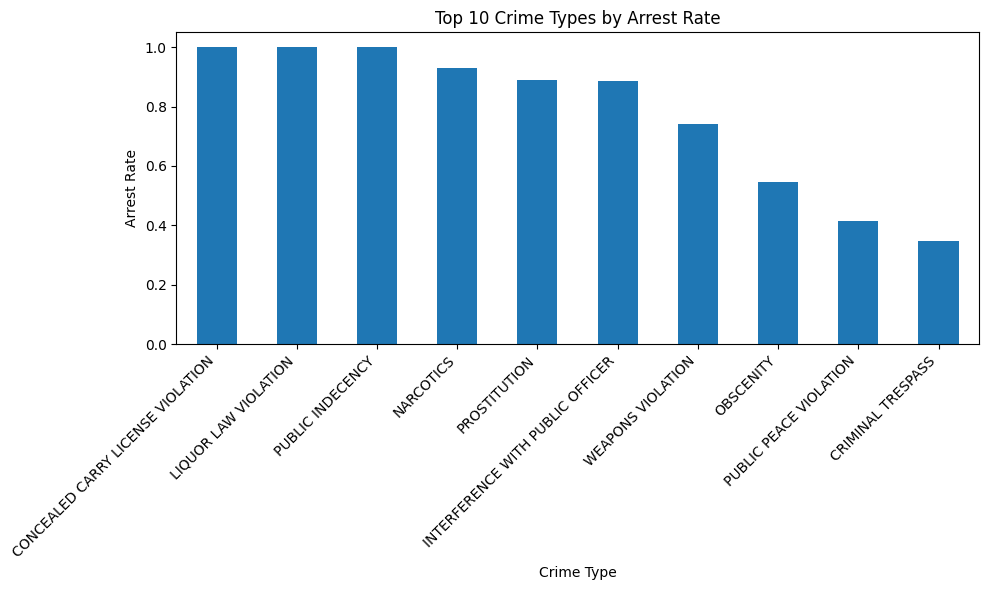

In [6]:
arrest_rates = df.groupby('primary_type')['arrest'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
arrest_rates.head(10).plot(kind='bar')
plt.title("Top 10 Crime Types by Arrest Rate")
plt.ylabel("Arrest Rate")
plt.xlabel("Crime Type")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation Question
Which crime types seem most likely to lead to arrest? Does this surprise you? <br>
Concealed carry license violation is most likely to lead to arrest. This does suprise me, I was expecting Narcotics to be more likely to lead to arrest. I also find it interesting that concealed carry license violation is much more likely to  lead to arrest than a weapons violation.


## Step 6: Feature Engineering

Machine learning models need numeric input. Since `primary_type` and `district` are categorical, we will convert them into dummy variables.


In [7]:
df = pd.get_dummies(df, columns=['primary_type', 'district'], drop_first=True)
df.head()

,arrest,domestic,latitude,longitude,primary_type_ASSAULT,primary_type_BATTERY,primary_type_BURGLARY,primary_type_CONCEALED CARRY LICENSE VIOLATION,primary_type_CRIMINAL DAMAGE,primary_type_CRIMINAL SEXUAL ASSAULT,...,district_14,district_15,district_16,district_17,district_18,district_19,district_20,district_22,district_24,district_25
0,False,False,41.770622,-87.733525,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,41.828075,-87.624904,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,41.975828,-87.697568,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,False,False,41.908928,-87.802695,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,False,False,41.757631,-87.585708,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Step 7: Define Features and Target

Here is the key setup:

- `X` = the input features used to make predictions
- `y` = the target variable we want to predict

In this assignment:

> `y = arrest`

So the model predicts whether an arrest was made.


In [8]:
X = df.drop('arrest', axis=1)
y = df['arrest']

## Step 8: Train/Test Split

We split the data so the model trains on one portion and is evaluated on unseen data.


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 9: Train the Random Forest Model


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Step 10: Evaluate the Model

We will use:
- **Accuracy**
- **Confusion Matrix**
- **Classification Report**


In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8688606581974593

Confusion Matrix:
[[7923  459]
 [ 852  763]]

Classification Report:
              precision    recall  f1-score   support

       False       0.90      0.95      0.92      8382
        True       0.62      0.47      0.54      1615

    accuracy                           0.87      9997
   macro avg       0.76      0.71      0.73      9997
weighted avg       0.86      0.87      0.86      9997



## Step 11: Feature Importance

Feature importance tells us which variables had the biggest influence on the model’s predictions.

A larger value means the model used that variable more heavily when making decisions.


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)
top_features

,0
latitude,0.327276
longitude,0.319954
primary_type_NARCOTICS,0.145276
primary_type_WEAPONS VIOLATION,0.060658
primary_type_INTERFERENCE WITH PUBLIC OFFICER,0.019783
domestic,0.010462
primary_type_CRIMINAL DAMAGE,0.009808
primary_type_CRIMINAL TRESPASS,0.009609
primary_type_MOTOR VEHICLE THEFT,0.008124
primary_type_BATTERY,0.007170


## Step 12: Visualize Feature Importance

This plot gives a clearer picture of what the model relied on most.


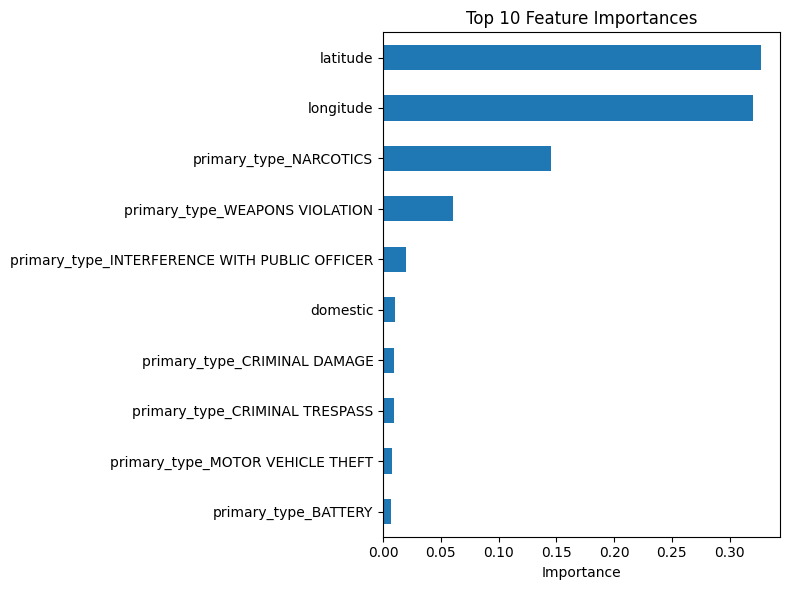

In [13]:
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Interpretation Questions
1. Which features matter the most? <br>
Lattitude matters the most, with longitude being almost as important.
2. Does the model seem to rely more on **location** or **crime type**? <br>
This model relies on location more.
3. What does that suggest about arrest outcomes in the dataset? <br>
This suggest that crimes committed in certain areas are more likely to lead to arrest than crimes committed in other areas.


## Step 13: Cross Validation

Cross validation helps us check whether the model performs consistently across different subsets of the data.


In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())

Cross-validation scores: [0.86686006 0.86826048 0.87156147 0.87506252 0.86115835]
Average cross-validation score: 0.8685805741722517


## Step 14: Reflection

Write a short reflection that answers the following:

1. What does the model do well? <Br>
The model does well predicting when arrests are not made (False), it has a high F1-score for no arrests meaning it performs well overall, and the cross validation score is high meaning that it performs similarly across different data splits.
2. What are its limitations? <br>
The model does not do well predicting when arrests are made. It only has 47% true positives. The F1-score for arrest is low meaning it does not perform well.
3. What does feature importance suggest about the strongest predictors of arrest? <br>
Feature importance suggest that location, latitude and longitude, is the strongest predictor of arrest.
4. Why is it important to remember that this model predicts **arrest outcomes** rather than crime itself? <br>
A crime can happen without an arrest, and not all crimes are reported. This means that just because an area has more arrest does not necessarily mean it has more crime.
5. Should a model like this be used in real-world policing decisions? Why or why not?
No, the accuracy is not perfect and there are many false positive and false negatives which can lead to unfair convictions or non convictions if this model was used in real world policing decisions.
